In [8]:
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import optuna
from skopt import BayesSearchCV
pd.set_option('display.max_columns', None)

In [9]:
training_df=pd.read_csv("../Datasets/training_df.csv")
training_df.fillna(0,inplace=True)
training_df.drop(['date','time'],axis=1,inplace=True)
training_df.head()

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,et0_fao_evapotranspiration,vapour_pressure_deficit,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.4600,95.42882,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,1012.03436,3.9,4.0,0.0,1.0,0.0,0.057978,7.421590,12.229406,112.833694,137.38599,11.879999,10.7600,13.110001,14.0100,21.910000,0.275,0.318,0.195,0.026,1
1,10.4535,95.42859,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,1011.91230,3.9,4.0,0.0,1.0,0.0,0.057956,7.421590,12.229406,112.833694,137.38599,11.879999,10.7535,13.103500,14.0035,21.903500,0.275,0.318,0.195,0.026,1
2,10.4145,95.42721,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,1011.18120,3.9,4.0,0.0,1.0,0.0,0.057823,7.421590,12.229406,112.833694,137.38599,11.879999,10.7145,13.064501,13.9645,21.864500,0.275,0.318,0.195,0.026,1
3,9.2235,99.66392,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,1010.78680,2.7,3.0,0.0,0.0,0.0,0.003924,5.937272,11.885453,75.963730,125.13428,13.320000,10.4235,12.823500,13.7235,21.923500,0.273,0.324,0.201,0.020,1
4,9.2430,99.66399,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,1011.15370,2.7,3.0,0.0,0.0,0.0,0.003929,5.937272,11.885453,75.963730,125.13428,13.320000,10.4430,12.842999,13.7430,21.942999,0.273,0.324,0.201,0.020,1


In [10]:
training_df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'precipitation', 'rain', 'snowfall',
       'snow_depth', 'weather_code', 'pressure_msl', 'surface_pressure',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'et0_fao_evapotranspiration', 'vapour_pressure_deficit',
       'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'wind_direction_100m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
       'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm',
       'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm',
       'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm',
       'soil_moisture_100_to_255cm', 'fire'],
      dtype='object')

In [11]:
training_df.shape

(113896, 31)

In [12]:
X=training_df.drop('fire',axis=1)
y=training_df['fire']

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
scaler = StandardScaler()

X_train_transformed = scaler.fit_transform(X_train)
X_test_transformed = scaler.transform(X_test)

In [15]:
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, n_jobs=-1, random_state=42)

In [22]:
xgb_model.fit(X_train_transformed, y_train)

c:\Users\abhir\anaconda3\envs\wildfire-prediction\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:13:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [23]:
xgb_model.get_booster().feature_names = X_train.columns.tolist()


In [17]:
# Predict
y_train_pred_xgb = xgb_model.predict(X_train_transformed)
y_test_pred_xgb = xgb_model.predict(X_test_transformed)


In [18]:
# Accuracy
train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)

print(f'Training Accuracy (XGBoost): {train_acc_xgb * 100:.2f}%')
print(f'Testing Accuracy (XGBoost): {test_acc_xgb * 100:.2f}%')

Training Accuracy (XGBoost): 87.24%
Testing Accuracy (XGBoost): 83.29%


Precision (XGBoost): 84.16%
Recall (XGBoost): 83.29%
F1 Score (XGBoost): 83.17%


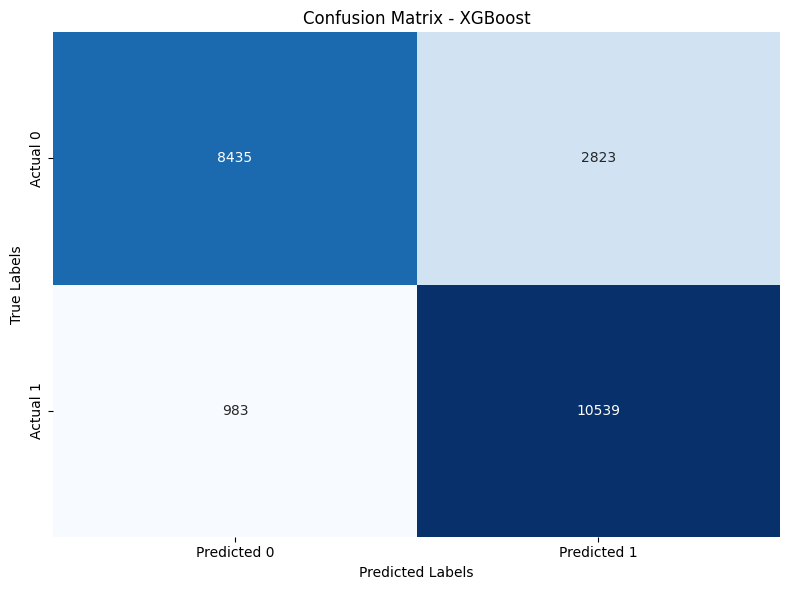

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.90      0.75      0.82     11258
           1       0.79      0.91      0.85     11522

    accuracy                           0.83     22780
   macro avg       0.84      0.83      0.83     22780
weighted avg       0.84      0.83      0.83     22780



In [19]:
# Precision, Recall, F1
precision = precision_score(y_test, y_test_pred_xgb, average='weighted')
recall = recall_score(y_test, y_test_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_test_pred_xgb, average='weighted')

print(f'Precision (XGBoost): {precision * 100:.2f}%')
print(f'Recall (XGBoost): {recall * 100:.2f}%')
print(f'F1 Score (XGBoost): {f1 * 100:.2f}%')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report (XGBoost):")
print(classification_report(y_test, y_test_pred_xgb))



AUC-ROC: 0.8995


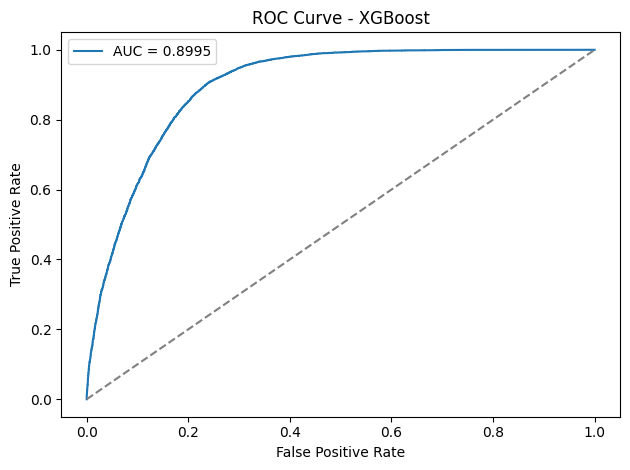

In [20]:
y_probs = xgb_model.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f'AUC-ROC: {auc:.4f}')

fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
X_train.columns == X.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

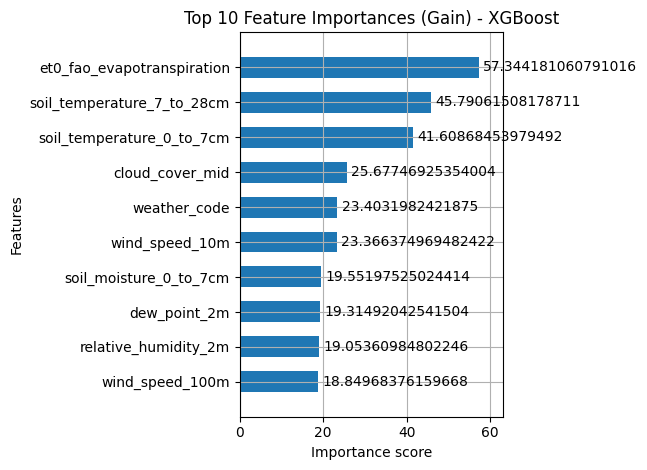

In [25]:
from xgboost import plot_importance

plot_importance(xgb_model, max_num_features=10, importance_type='gain', height=0.6)
plt.title('Top 10 Feature Importances (Gain) - XGBoost')
plt.tight_layout()
plt.show()

In [27]:
from sklearn.model_selection import StratifiedKFold
from skopt.space import Real, Integer

# Define model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

# Search space
search_space_xgb = {
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(4, 12),
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(0, 5)
}

# 3-fold CV
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Bayesian Optimization
bayes_search_xgb = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=search_space_xgb,
    n_iter=15,  # faster
    scoring='accuracy',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit
bayes_search_xgb.fit(X_train_transformed, y_train)

# Best params
print("Best parameters:", bayes_search_xgb.best_params_)
print(f"Best CV Accuracy: {bayes_search_xgb.best_score_:.4f}")


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\abhir\anaconda3\envs\wildfire-prediction\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:19:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: OrderedDict([('colsample_bytree', 1.0), ('gamma', 0.0), ('learning_rate', 0.2), ('max_depth', 10), ('n_estimators', 228), ('subsample', 0.9542262311998893)])
Best CV Accuracy: 0.8516


In [28]:
best_xgboost_model = xgb.XGBClassifier(
    learning_rate=bayes_search_xgb.best_params_['learning_rate'],
    max_depth=bayes_search_xgb.best_params_['max_depth'],
    n_estimators=bayes_search_xgb.best_params_['n_estimators'],
    subsample=bayes_search_xgb.best_params_['subsample'],
    colsample_bytree=bayes_search_xgb.best_params_['colsample_bytree'],
    gamma=bayes_search_xgb.best_params_['gamma'],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

In [29]:
best_xgboost_model.fit(X_train_transformed, y_train)

c:\Users\abhir\anaconda3\envs\wildfire-prediction\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:21:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=228, n_jobs=None,
              num_parallel_tree=None, ...)

In [30]:
# Predictions
y_train_pred_xgb = best_xgboost_model.predict(X_train_transformed)
y_test_pred_xgb = best_xgboost_model.predict(X_test_transformed)

In [31]:
print(f'Training Accuracy: {accuracy_score(y_train, y_train_pred_xgb) * 100:.2f}%')
print(f'Testing Accuracy: {accuracy_score(y_test, y_test_pred_xgb) * 100:.2f}%')

Training Accuracy: 98.61%
Testing Accuracy: 87.14%


Precision: 87.42%
Recall: 87.14%
F1 Score: 87.11%


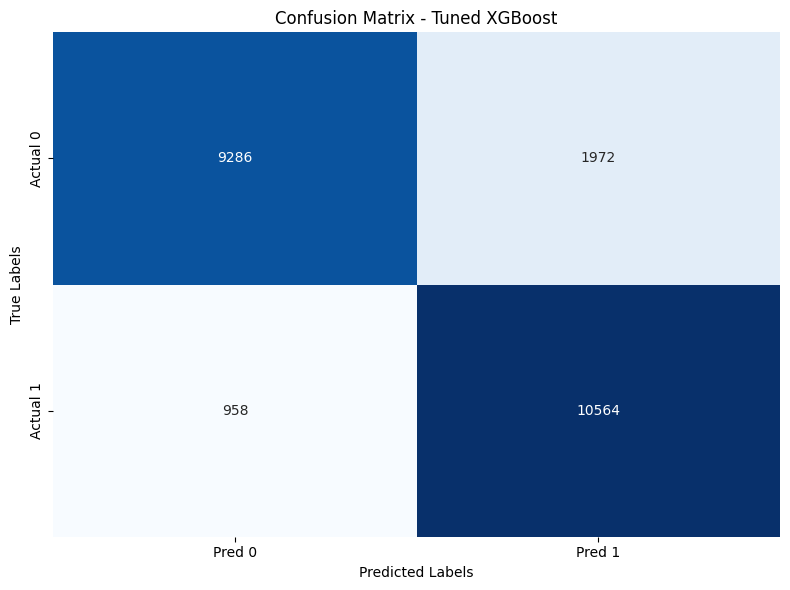

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86     11258
           1       0.84      0.92      0.88     11522

    accuracy                           0.87     22780
   macro avg       0.87      0.87      0.87     22780
weighted avg       0.87      0.87      0.87     22780



In [32]:
# Precision, Recall, F1
precision = precision_score(y_test, y_test_pred_xgb, average='weighted')
recall = recall_score(y_test, y_test_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_test_pred_xgb, average='weighted')

print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix - Tuned XGBoost')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_test_pred_xgb))


AUC-ROC: 0.9352


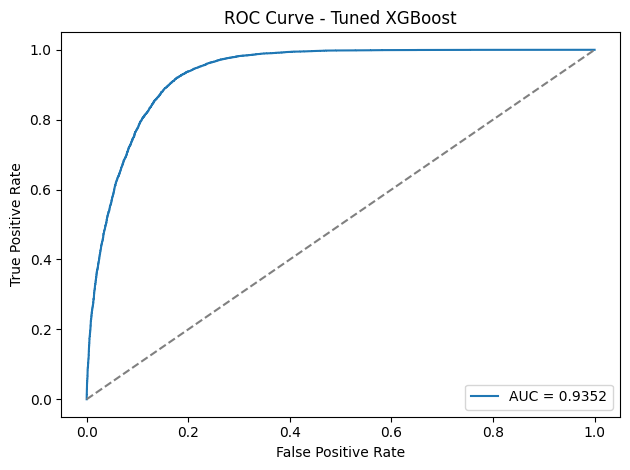

In [33]:
y_probs = best_xgboost_model.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f'AUC-ROC: {auc:.4f}')

fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned XGBoost')
plt.legend()
plt.tight_layout()
plt.show()


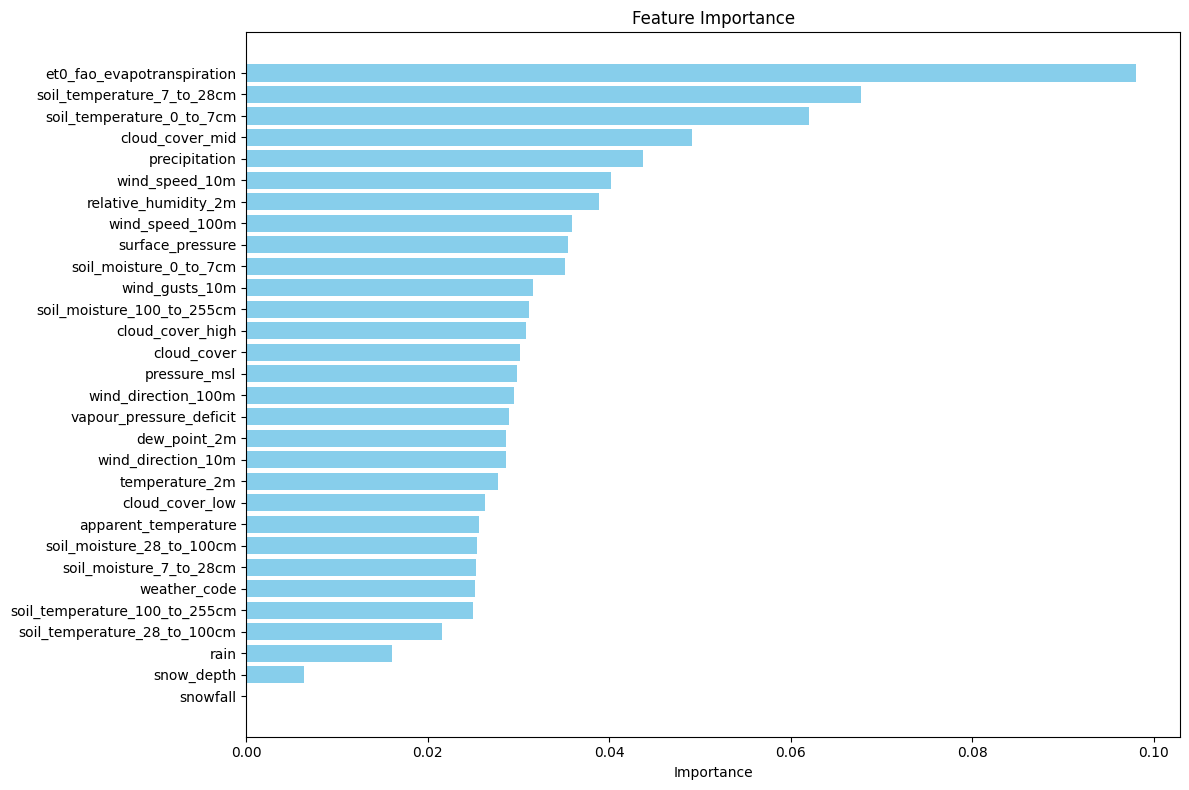

In [35]:
importances = best_xgboost_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()
